# 03 · Model training, evaluation and explainability
This notebook runs the full training script (`src/train.py`) and walks through its results.

**Protocol**
1. Rule-based cleaning on the full file (duplicates, impossible values → NaN). No statistics are learned here.
2. Stratified 80/20 train/test split (seed 42). The test set is untouched until final evaluation.
3. Each candidate model is wrapped in a `Pipeline(preprocess → model)`, so imputation, scaling and encoding
   are re-fitted inside every CV fold → **no data leakage**.
4. Model selection by **5-fold cross-validation on the training set only**: macro-F1 for classifiers,
   RMSE for the probability regressor.
5. The selected models are evaluated once on the test set.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
import warnings; warnings.filterwarnings("ignore")
import json, pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
from src.train import build_preprocessor, make_pipeline
from src.utils import FIG_DIR, METRICS_DIR, REPORTS_DIR, MODELS_DIR

## The preprocessing pipeline

In [2]:
build_preprocessor()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columns', ...), ('select', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

## Train and compare all models

In [3]:
from src import train
meta = train.main()

Loaded raw dataset: (1215, 20)
rows_in                         : 1215
duplicates_removed              : 15
rows_missing_target_removed     : 0
impossible_values_set_to_nan    : {'cgpa': 2, 'attendance_pct': 2, 'coding_score': 1, 'study_hours_per_week': 1}
missing_values_after_cleaning   : {'cgpa': 2, 'attendance_pct': 26, 'coding_score': 1, 'communication_score': 24, 'certifications': 24, 'internship': 24, 'extracurricular_score': 24, 'study_hours_per_week': 25}
rows_out                        : 1200
Train: 960 rows  |  Test: 240 rows (held out, untouched until final evaluation)

=== Academic performance ===


  Logistic Regression  CV F1=0.831±0.016  test F1=0.824
  Decision Tree        CV F1=0.802±0.032  test F1=0.786


  Random Forest        CV F1=0.826±0.023  test F1=0.797


  Gradient Boosting    CV F1=0.819±0.030  test F1=0.799


  XGBoost              CV F1=0.836±0.025  test F1=0.812
  -> selected: XGBoost (highest mean cross-validated macro-F1)

=== Placement readiness ===


  Logistic Regression  CV F1=0.781±0.029  test F1=0.835
  Decision Tree        CV F1=0.621±0.020  test F1=0.651


  Random Forest        CV F1=0.691±0.040  test F1=0.751


  Gradient Boosting    CV F1=0.694±0.023  test F1=0.719


  XGBoost              CV F1=0.710±0.018  test F1=0.754
  -> selected: Logistic Regression (highest mean cross-validated macro-F1)

=== Placement probability (regression) ===
  Ridge Regression     CV RMSE=14.76  test RMSE=12.78  test R²=0.883


  Decision Tree        CV RMSE=15.80  test RMSE=14.67  test R²=0.846


  Random Forest        CV RMSE=11.48  test RMSE=11.21  test R²=0.910


  Gradient Boosting    CV RMSE=10.59  test RMSE=10.39  test R²=0.923


  XGBoost              CV RMSE=10.35  test RMSE=9.87  test R²=0.930
  -> selected: XGBoost (lowest mean cross-validated RMSE)


Background dataset has 240 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=240 when initializing the masker.



All artifacts saved. Selected models: {'academic': 'XGBoost', 'placement': 'Logistic Regression', 'probability': 'XGBoost'}


## Model-comparison tables

In [4]:
for name in ["academic", "placement"]:
    t = pd.read_csv(METRICS_DIR / f"{name}_model_comparison.csv")
    display(Markdown(f"### {name.title()} — selected: **{meta['selected_models'][name]}**"))
    display(t[["model","cv_f1","cv_f1_std","test_accuracy","test_precision","test_recall","test_f1","test_roc_auc"]].round(3))
t = pd.read_csv(METRICS_DIR / "probability_model_comparison.csv")
display(Markdown(f"### Placement probability — selected: **{meta['selected_models']['probability']}**"))
display(t.round(3))

### Academic — selected: **XGBoost**

,model,cv_f1,cv_f1_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,XGBoost,0.836,0.025,0.800,0.814,0.810,0.812,0.959
1,Logistic Regression,0.831,0.016,0.817,0.829,0.821,0.824,0.967
2,Random Forest,0.826,0.024,0.783,0.810,0.788,0.797,0.953
3,Gradient Boosting,0.819,0.030,0.788,0.804,0.797,0.799,0.958
4,Decision Tree,0.802,0.032,0.767,0.797,0.777,0.786,0.934


### Placement — selected: **Logistic Regression**

,model,cv_f1,cv_f1_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Logistic Regression,0.782,0.029,0.867,0.842,0.829,0.835,0.975
1,XGBoost,0.710,0.018,0.796,0.755,0.756,0.754,0.947
2,Gradient Boosting,0.694,0.023,0.771,0.719,0.721,0.719,0.943
3,Random Forest,0.691,0.040,0.804,0.757,0.750,0.751,0.946
4,Decision Tree,0.621,0.020,0.712,0.658,0.651,0.651,0.882


### Placement probability — selected: **XGBoost**

,model,cv_mae,cv_rmse,cv_rmse_std,cv_r2,test_mae,test_rmse,test_r2
0,XGBoost,7.404,10.349,0.660,0.922,7.075,9.867,0.930
1,Gradient Boosting,7.641,10.586,0.705,0.918,7.404,10.390,0.923
2,Random Forest,8.145,11.479,0.862,0.904,7.950,11.211,0.910
3,Ridge Regression,12.164,14.760,0.860,0.842,10.009,12.778,0.883
4,Decision Tree,10.871,15.800,0.619,0.818,9.981,14.673,0.846


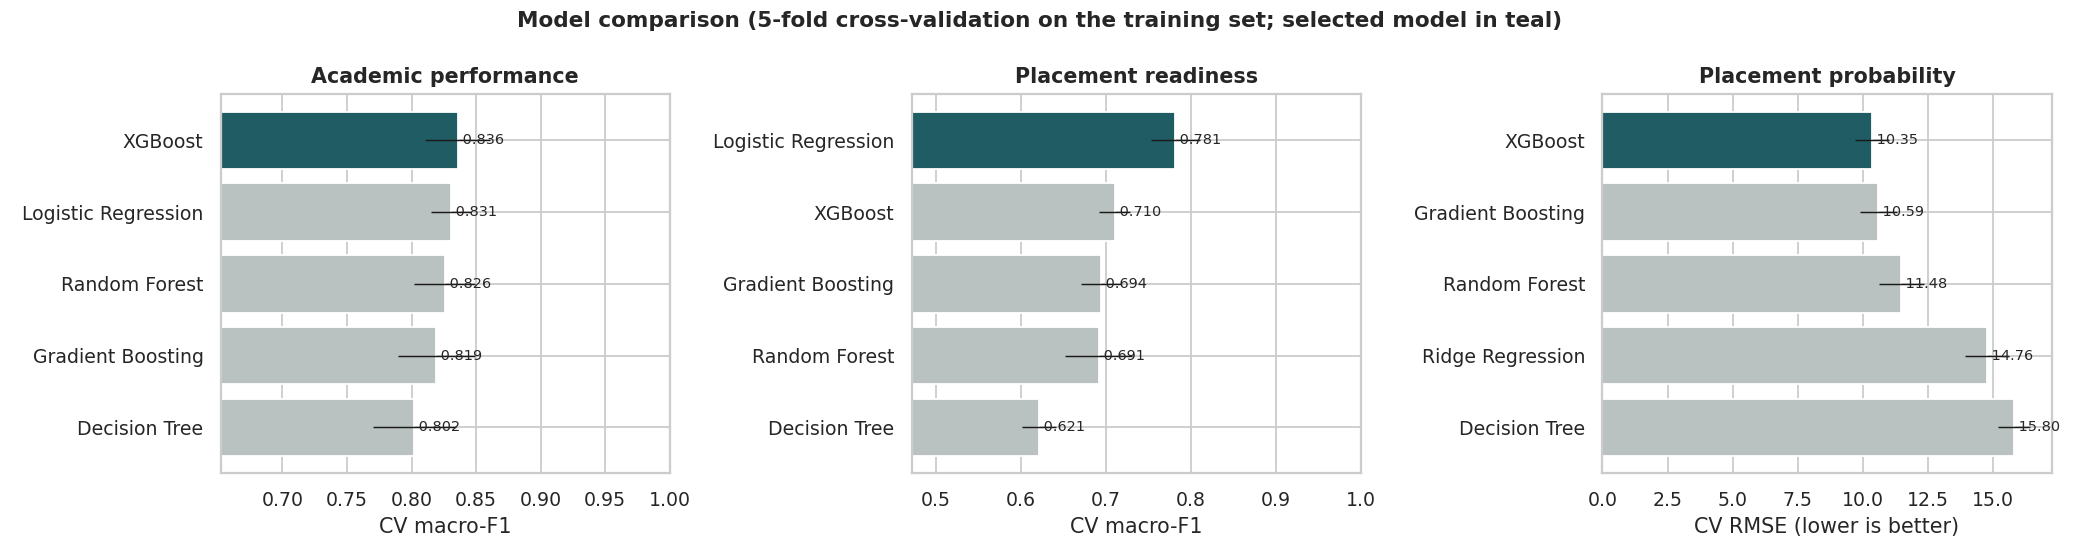

In [5]:
display(Image(FIG_DIR / 'model_comparison.png'))

**Why these models?** Selection follows the CV score, not preference. For placement readiness, plain Logistic
Regression wins because the synthetic placement score is (by construction) close to a linear function of the
inputs; tree ensembles need more data to approximate such smooth boundaries. For the probability target, the
logistic squashing makes the relationship non-linear, which is where XGBoost / Gradient Boosting do better.

## Confusion matrices (test set)

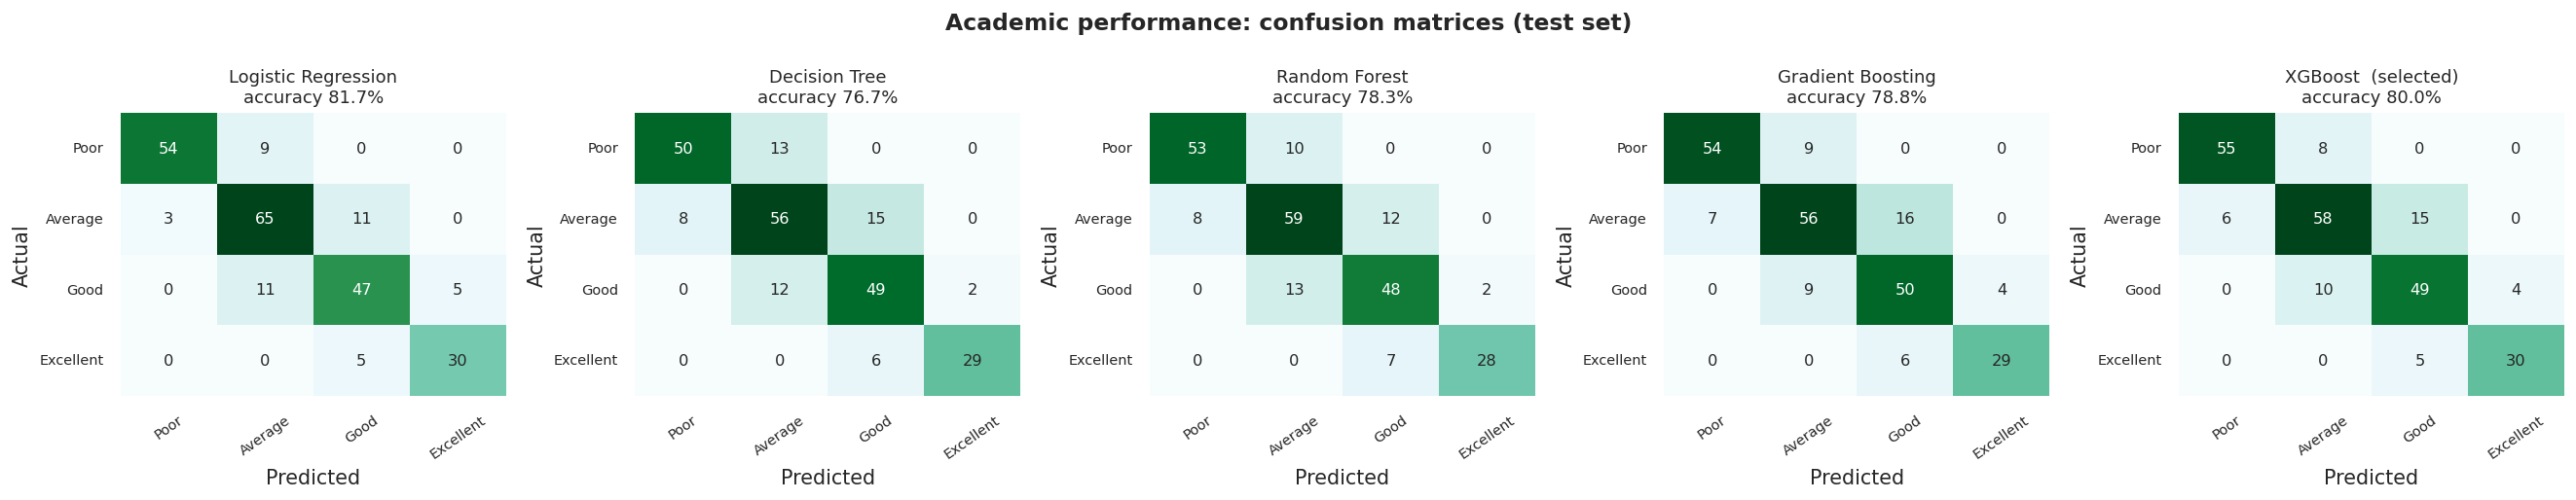

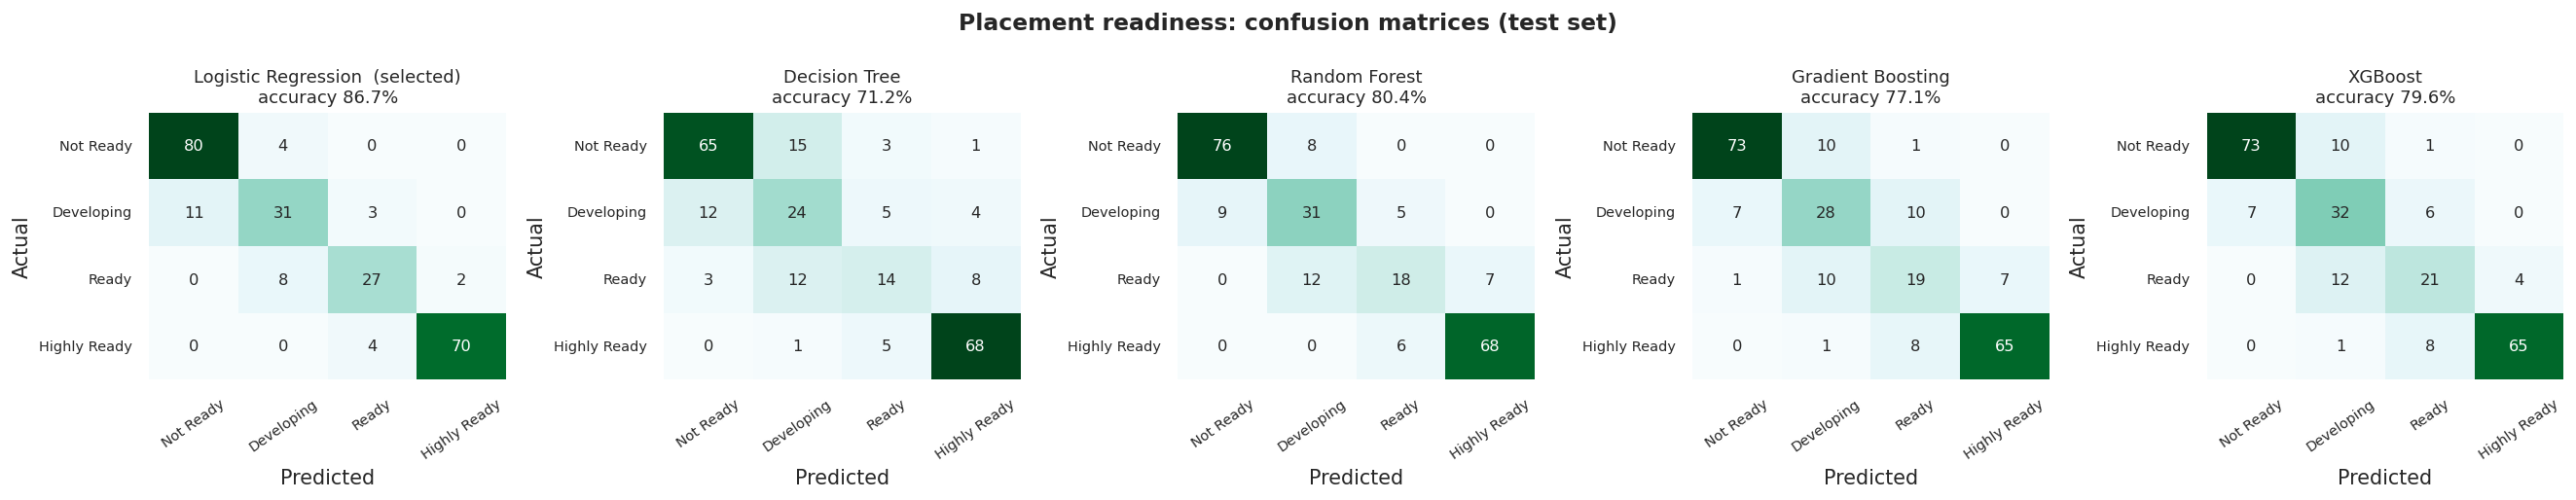

In [6]:
display(Image(FIG_DIR / 'confusion_matrices_academic_all.png'))
display(Image(FIG_DIR / 'confusion_matrices_placement_all.png'))

In [7]:
print((REPORTS_DIR / 'academic_classification_report.txt').read_text())
print((REPORTS_DIR / 'placement_classification_report.txt').read_text())

Selected model: XGBoost

              precision    recall  f1-score   support

        Poor      0.902     0.873     0.887        63
     Average      0.763     0.734     0.748        79
        Good      0.710     0.778     0.742        63
   Excellent      0.882     0.857     0.870        35

    accuracy                          0.800       240
   macro avg      0.814     0.811     0.812       240
weighted avg      0.803     0.800     0.801       240

Selected model: Logistic Regression

              precision    recall  f1-score   support

   Not Ready      0.879     0.952     0.914        84
  Developing      0.721     0.689     0.705        45
       Ready      0.794     0.730     0.761        37
Highly Ready      0.972     0.946     0.959        74

    accuracy                          0.867       240
   macro avg      0.842     0.829     0.835       240
weighted avg      0.865     0.867     0.865       240



Almost all errors are between **adjacent** categories (e.g. Developing ↔ Ready), which is expected because the categories are cut from a continuous score with noise.

## Placement-probability regression

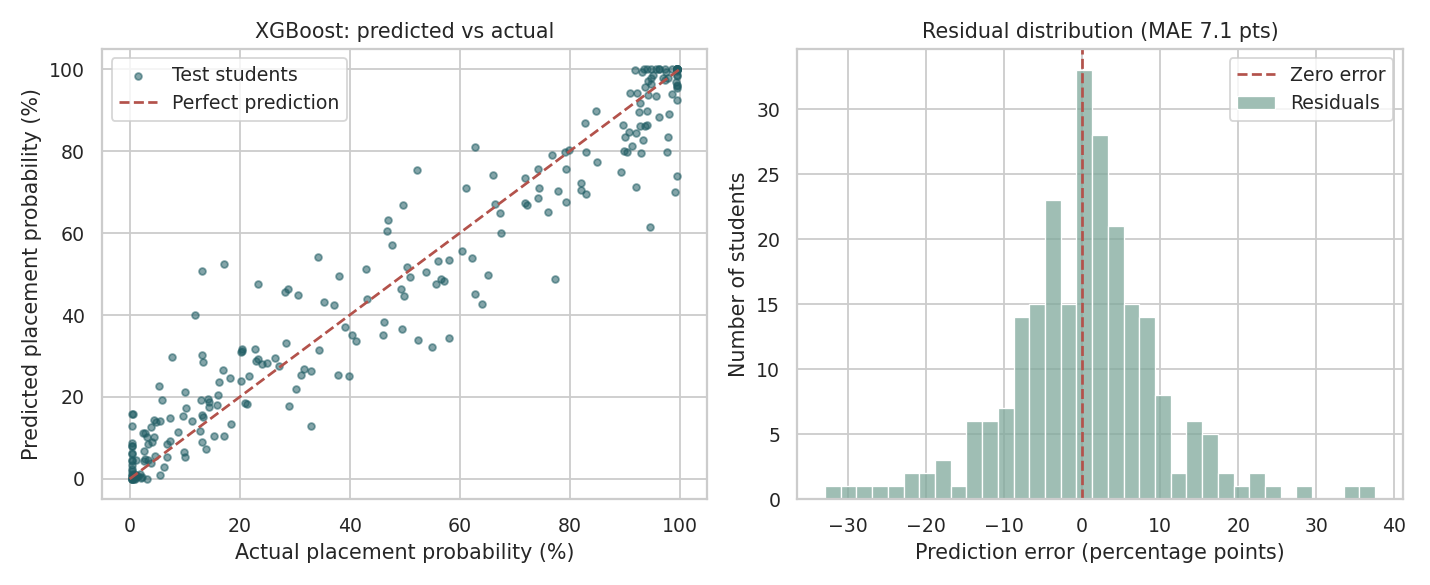

In [8]:
display(Image(FIG_DIR / 'probability_regression.png'))

## Feature importance

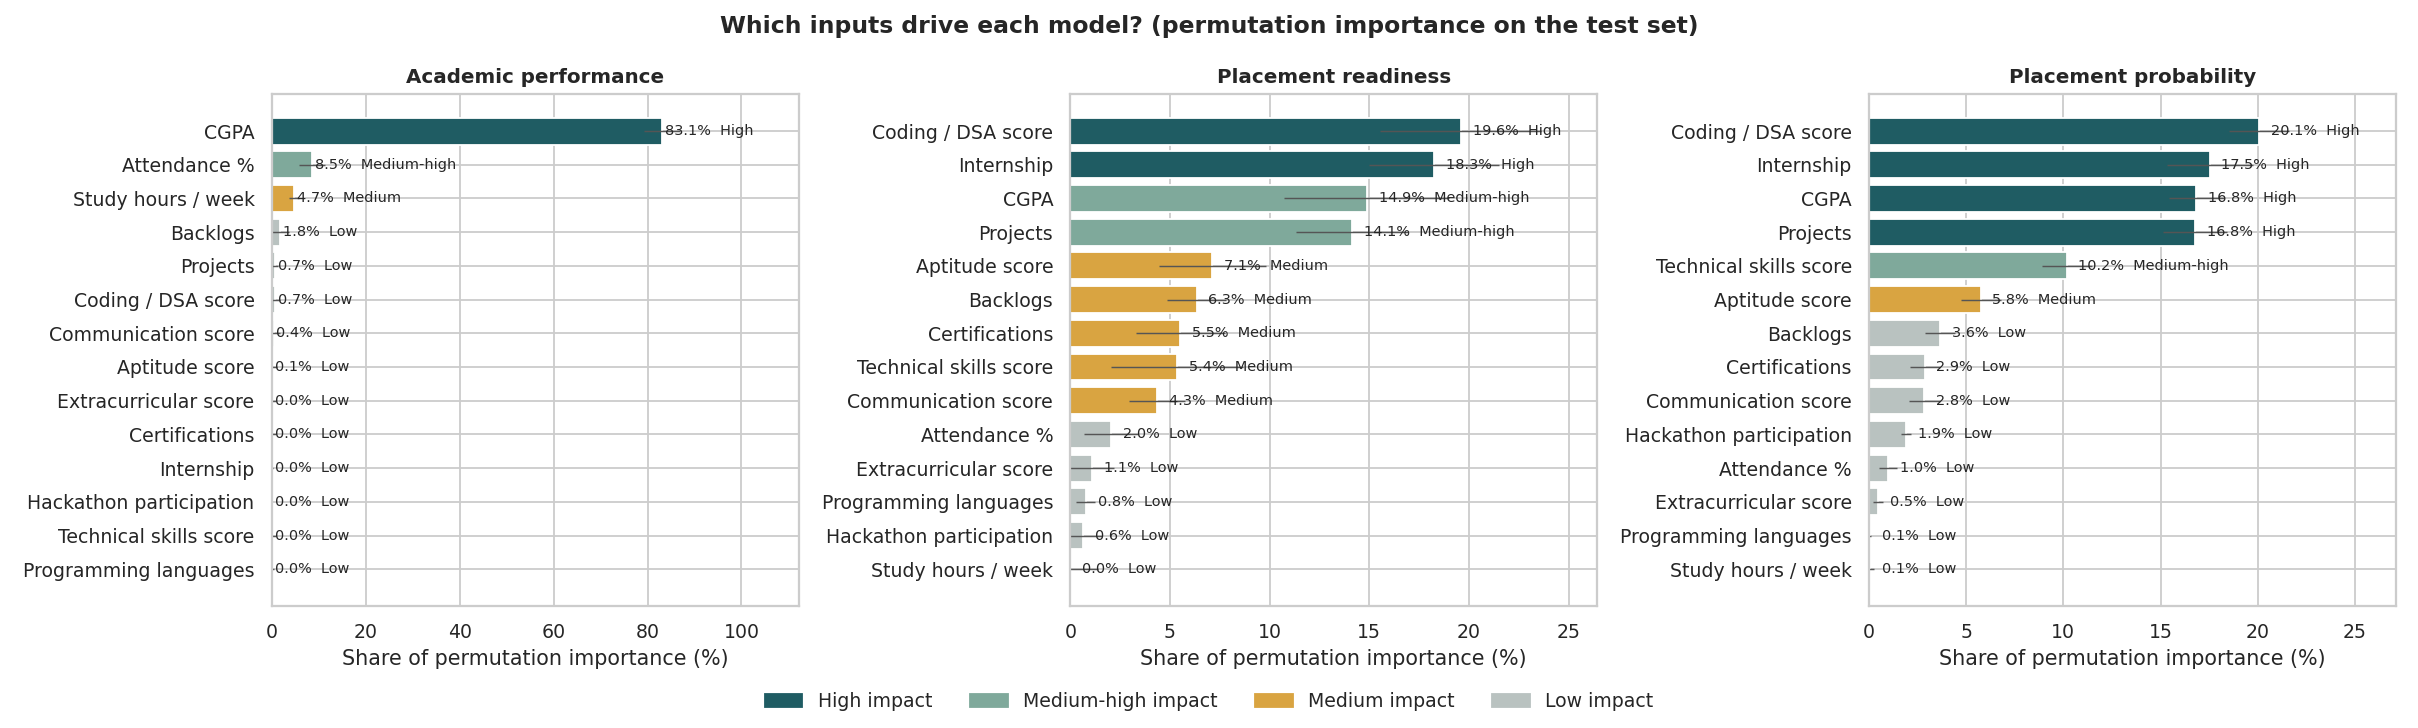

,label,share,impact
0,Coding / DSA score,0.196,High
1,Internship,0.182,High
2,CGPA,0.149,Medium-high
3,Projects,0.141,Medium-high
4,Aptitude score,0.071,Medium
5,Backlogs,0.063,Medium
6,Certifications,0.055,Medium
7,Technical skills score,0.054,Medium
8,Communication score,0.043,Medium
9,Attendance %,0.020,Low


In [9]:
display(Image(FIG_DIR / 'feature_importance.png'))
pd.read_csv(METRICS_DIR / 'feature_importance_placement.csv')[['label','share','impact']].round(3)

## SHAP explanations

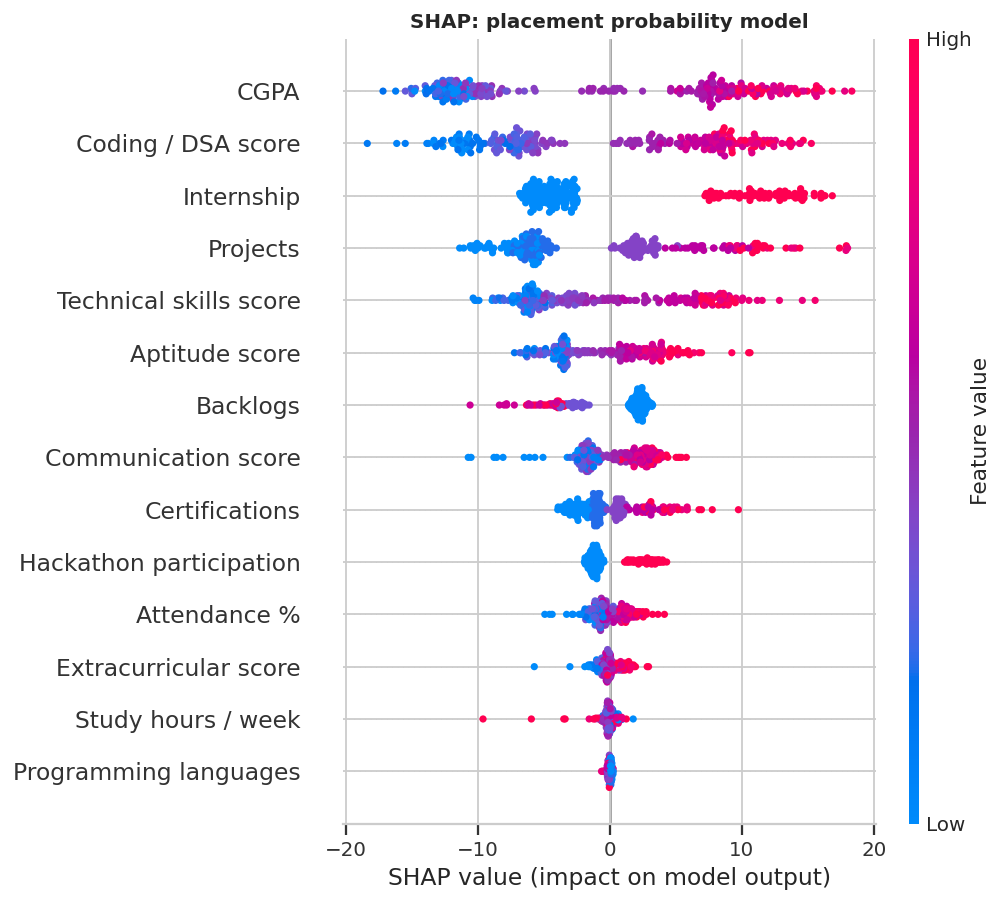

In [10]:
display(Image(FIG_DIR / 'shap_summary_probability.png'))

### Individual prediction explanation

In [11]:
from src.predict import StudentPredictor, EXAMPLE_STUDENT
p = StudentPredictor()
student = dict(EXAMPLE_STUDENT, cgpa=7.4, coding_score=64, internship="No", projects=2)
res = p.predict(student)
print(res.summary())
top = res.top_factors(8)[::-1]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([f"{f.label} = {f.value}" for f in top], [f.contribution for f in top],
        color=["#1F5C63" if f.contribution > 0 else "#B3524B" for f in top], label="SHAP contribution")
ax.axvline(0, color="black", lw=0.8)
ax.set_title(f"Why {res.placement_probability:.0f}%? (baseline {res.baseline_probability:.0f}%)")
ax.set_xlabel("Contribution (percentage points)"); ax.set_ylabel("Feature = value"); ax.legend()
fig.savefig(FIG_DIR / "shap_individual_example.png", dpi=130, bbox_inches="tight"); plt.show()

Academic Performance      : Good (93% model confidence)
Placement Readiness       : Highly Ready (61% model confidence)
Estimated Placement Prob. : 83%
Main factors (SHAP (tree), vs. average student at 48%):
  Technical skills score   =     68    +9.5 pts
  CGPA                     =    7.4    +9.0 pts
  Coding / DSA score       =     64    +6.2 pts
  Internship               =     No    -5.0 pts
  Aptitude score           =     72    +3.4 pts
  Communication score      =     70    +3.3 pts


## Fairness audit (gender is not a model input)

In [12]:
pd.read_csv(METRICS_DIR / 'fairness_by_gender.csv')

,gender,students,readiness_accuracy,mean_actual_probability,mean_predicted_probability,pct_predicted_ready_or_above
0,Female,87.0,0.885,50.667,50.643,0.460
1,Male,147.0,0.850,43.948,44.385,0.415
2,Other,6.0,1.000,73.600,71.558,0.833


The *Other* group is very small in the test set, so its numbers are unstable. Excluding a sensitive attribute does
not by itself guarantee fairness (other features can act as proxies), which is why outcomes are audited per group.

## Conclusion
- All three tasks are learned well **on synthetic data** (see tables above).
- Top drivers match the generator's design: coding score, CGPA, internship, projects and technical skills.
- These numbers measure how well the model recovers the simulator's rules — **not** real-world predictive power.